Defining model architectures...
Initializing models and loading weights...
Weights successfully loaded!
Initializing webcam with Standalone Knuckle-Pinch Script...


<IPython.core.display.Javascript object>

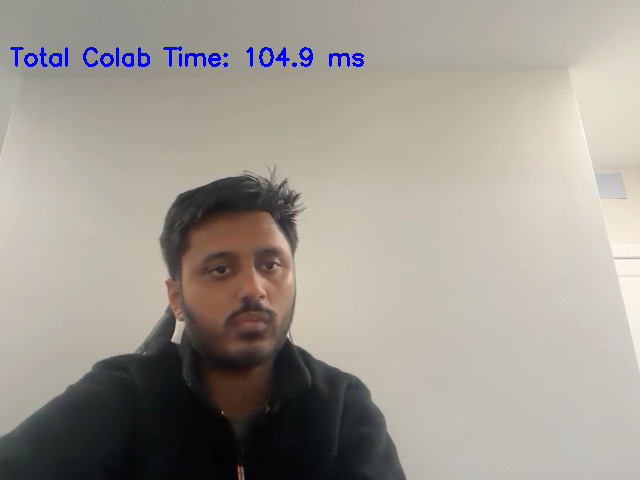

Live stream stopped by user.


In [ ]:
# ==========================================================================================
# STANDALONE WEBCAM INFERENCE SCRIPT (MODULAR VERSION)
# ------------------------------------------------------------------------------------------
# This cell is refactored to improve modularity and reusability.
# ==========================================================================================

import os
import cv2
import time
import torch
import torch.nn as nn
import numpy as np
import gdown
from torchvision.models import mobilenet_v3_small
from torchvision.models.detection.ssd import SSD
from torchvision.models.detection.anchor_utils import DefaultBoxGenerator
from IPython.display import display, Javascript, clear_output
from google.colab.output import eval_js
from base64 import b64decode
import io
from PIL import Image as PILImage

# --- CONFIGURATION ---
CONFIG = {
    'stage_one': {
        'file_id': '11ELybE7ZdW0foxAMmkTS99cuQ3Vnr4ZN',
        'weights_path': 'stage1_finetuned_weights.pth',
        'model_fn': 'build_stage_one_detection_model'
    },
    'stage_two': {
        'file_id': '1OO8Q_rk1iJy3c_9_4eQwZwkRbmRl0Yq-',
        'weights_path': 'best_stage_two_model.pth',
        'model_fn': 'AirPointerKeypointNet'
    }
}

# --- UTILITY FUNCTIONS ---
def download_weights(file_id, output_path):
    if not os.path.exists(output_path):
        gdown.download(id=file_id, output=output_path, quiet=False)

def load_model_weights(model, weights_path):
    try:
        model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
        print(f"Weights loaded for {weights_path}")
    except Exception as e:
        print(f"Error loading weights for {weights_path}: {e}")

# --- MODEL DEFINITIONS ---
def build_stage_one_detection_model():
    feature_extractor = mobilenet_v3_small(weights='DEFAULT').features
    feature_extractor.out_channels = [576]
    box_generator = DefaultBoxGenerator(aspect_ratios=[[2, 3]], min_ratio=0.2, max_ratio=0.95)
    return SSD(feature_extractor, num_classes=2, anchor_generator=box_generator, size=(320, 320))

class AirPointerKeypointNet(nn.Module):
    def __init__(self):
        super(AirPointerKeypointNet, self).__init__()
        self.backbone = mobilenet_v3_small(weights='DEFAULT').features
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(576, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 21, kernel_size=1)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        features = self.backbone(x)
        heatmaps = self.decoder(features)
        return self.sigmoid(heatmaps)

# --- INITIALIZATION ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
models = {}

for stage, config in CONFIG.items():
    print(f"Initializing {stage} model...")
    model_fn = globals()[config['model_fn']]
    model = model_fn()
    download_weights(config['file_id'], config['weights_path'])
    load_model_weights(model, config['weights_path'])
    model.to(device).eval()
    models[stage] = model
print("All models initialized successfully!")